In [ ]:
import json
import os
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from transformers import AutoModelForCausalLM, AutoTokenizer
import matplotlib.pyplot as plt
import seaborn as sns

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_name = "openai/gpt-oss-20b"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name, output_hidden_states=True, output_attentions=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)
model.eval()

[transformers] MXFP4 quantization requires the `kernels` package: `pip install kernels>=0.12.0`. We will default to dequantizing the model to bf16.
[transformers] The following generation flags are not valid and may be ignored: ['output_attentions', 'output_hidden_states']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Loading weights: 100%|██████████| 411/411 [00:50<00:00,  8.17it/s]


GptOssForCausalLM(
  (model): GptOssModel(
    (embed_tokens): Embedding(201088, 2880, padding_idx=199999)
    (layers): ModuleList(
      (0-23): 24 x GptOssDecoderLayer(
        (self_attn): GptOssAttention(
          (q_proj): Linear(in_features=2880, out_features=4096, bias=True)
          (k_proj): Linear(in_features=2880, out_features=512, bias=True)
          (v_proj): Linear(in_features=2880, out_features=512, bias=True)
          (o_proj): Linear(in_features=4096, out_features=2880, bias=True)
        )
        (mlp): GptOssMLP(
          (router): GptOssTopKRouter()
          (experts): GptOssExperts()
        )
        (input_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
        (post_attention_layernorm): GptOssRMSNorm((2880,), eps=1e-05)
      )
    )
    (norm): GptOssRMSNorm((2880,), eps=1e-05)
    (rotary_emb): GptOssRotaryEmbedding()
  )
  (lm_head): Linear(in_features=2880, out_features=201088, bias=False)
)

In [7]:
def draw_per_layer_heatmap(hidden_states,out_f_name):

    seq_len = hidden_states[0].shape[1]

    fig, axes = plt.subplots(
        nrows=num_layers,
        ncols=1,
        figsize=(12, 2 * num_layers),
        sharex=True
    )

    for i, ax in enumerate(axes):
        hs = hidden_states[i][0].detach().float().cpu().numpy()  # (seq_len, hidden_dim)
        sns.heatmap(
            hs,
            cmap="viridis",
            cbar=False,
            ax=ax
        )
        ax.set_ylabel(f"L{i}")

    axes[-1].set_xlabel("Hidden dimension")
    plt.suptitle("Hidden states across all layers", y=1.02)
    plt.tight_layout()
    plt.savefig(f"./{out_f_name}.png")
    plt.show()

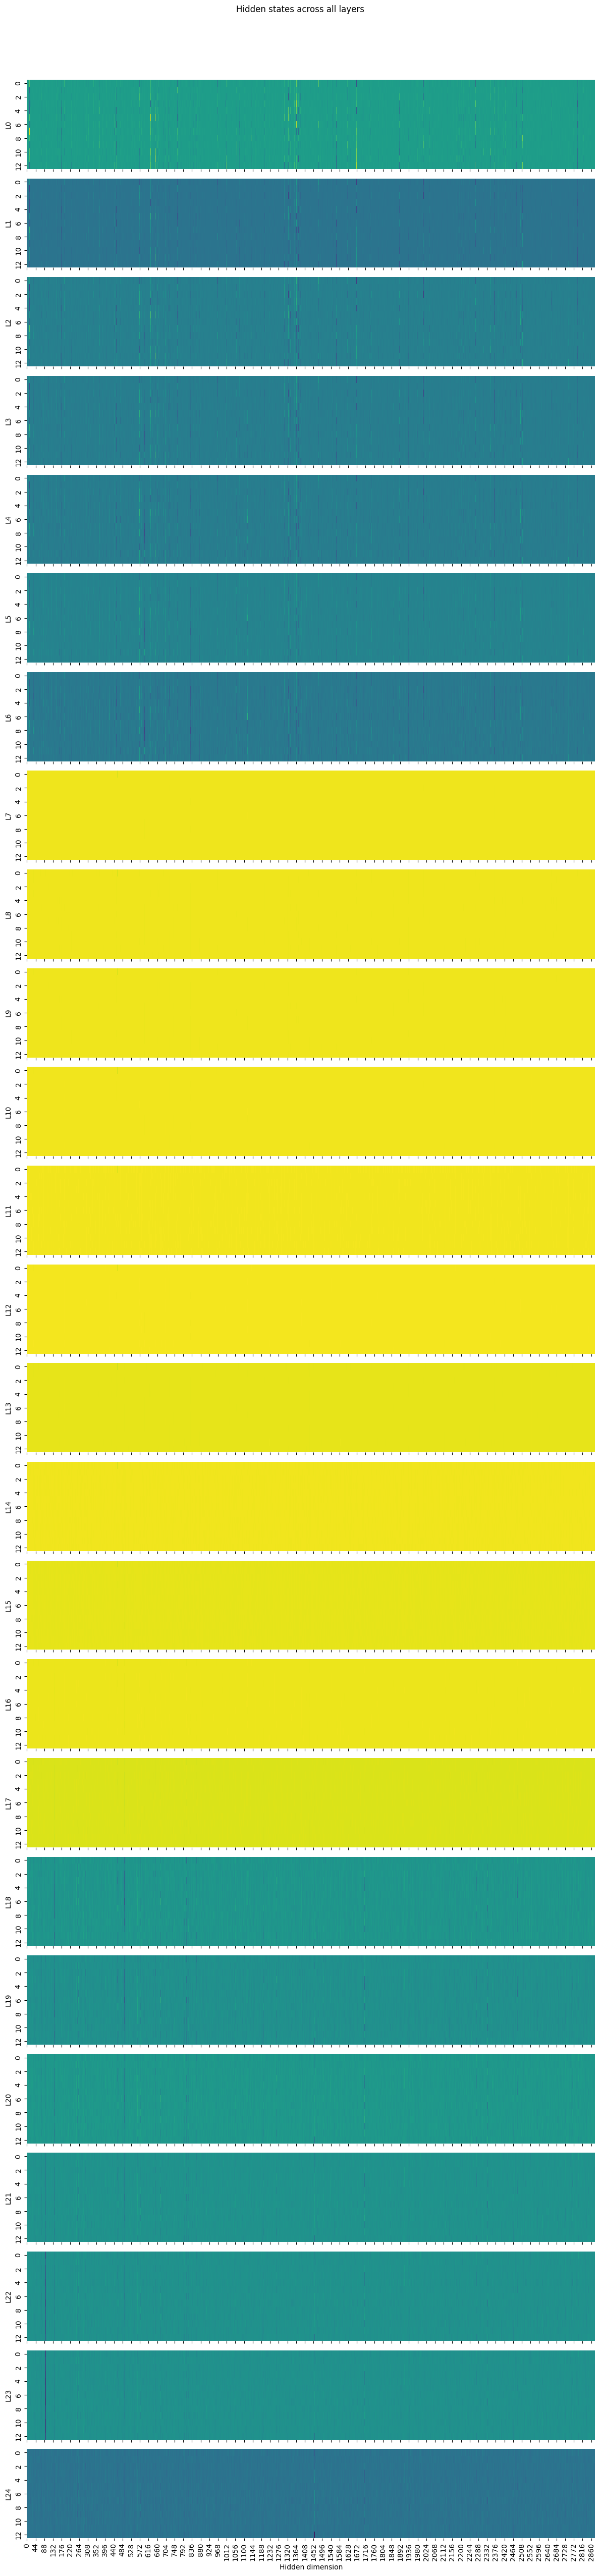

Layers: 25
torch.Size([1, 13, 2880])


KeyboardInterrupt: 

In [ ]:
with open("./prompts.json","r") as prompts_f:

    pf=json.load(prompts_f)

    layer_out_global_avg=[]

    for p_idx,prompt in enumerate(pf):

        text = prompt
        inputs = tokenizer(text, return_tensors="pt").to(device)

        outputs = model(**inputs)
        logits = outputs.logits  # shape: [batch, seq_len, vocab_size]

        # print(outputs.hidden_states)

        # un plot per layer
        # per ogni subplot: x->dimensioni per ogni token, y=token in input(parola)

        # Layer iniziali: token ancora legati a forma, vocabolario, sequenza
        # Layer medi: pattern semantici, relazioni tra token
        # Layer finali: rappresentazioni per la predizione del prossimo token 

        hidden_states=outputs.hidden_states

        #draw_per_layer_heatmap(hidden_states,"test")

        num_layers = len(hidden_states)

        print("Layers: "+str(num_layers))
        print(hidden_states[0].shape)

        layer_out_avg=[0] * len(hidden_states)

        if len(layer_out_global_avg)==0:
            layer_out_global_avg=[0]*len(hidden_states)

        for idx,hs in enumerate(hidden_states):
            for hs_dim in hs:
                for hs_channels in hs_dim:
                    for hs_tokens in hs_channels:
                        hs_tokens_cpu = hs_tokens.detach().to("cpu").item()
                        layer_out_avg[idx]+=hs_tokens_cpu/(len(hs)*len(hs_dim)*len(hs_channels))

        for el_idx,el in enumerate(layer_out_avg):
            layer_out_global_avg[el_idx]+=layer_out_avg[el_idx]/len(hidden_states)

        print(layer_out_avg)

        with open("./gpt_out/prompt_"+str(p_idx+1)+".json","w") as f:
            f.write(json.dumps(layer_out_avg))

        plt.plot(range(len(hidden_states)),layer_out_avg)
        plt.savefig("./gpt_out/prompt_"+str(p_idx+1)+".png")
        plt.show()

with open("./gpt_out/global.json","w") as f:
    f.write(json.dumps(layer_out_global_avg))

plt.plot(range(len(layer_out_global_avg)),layer_out_global_avg)
plt.savefig("./gpt_out/global.png")
plt.show()